<a href="https://colab.research.google.com/github/burka5032/Obfuscation-Resilient/blob/main/AU_v2_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import numpy as np
import pandas as pd

# 1. Prompt file upload in Colab
print("Please upload 'AU-PEMal-2025-V2.csv':")
uploaded = files.upload()

input_file = "AU-PEMal-2025-V2.csv"
output_file = "AU-PEMal-2025-V2_Cleaned.csv"

# 2. Load raw dataset
df = pd.read_csv(input_file)
print(f"Initial Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 3. Drop non-predictive identifier column (sha1 hash)
if "sha1" in df.columns:
    df = df.drop(columns=["sha1"])
    print("Dropped non-predictive hash column: 'sha1'")

# 4. Convert PE Header Hexadecimal columns ('0x...') to numeric integers
hex_cols = [
    "EntryPoint",
    "SizeOfCode",
    "SizeOfImage",
    "SizeOfInitializedData",
    "SizeOfUninitializedData",
    "rdata_VirtualSize",
    "rdata_VirtualAddress",
    "rdata_SizeOfRawData",
    "rdata_PointerToRawData",
    "text_VirtualSize",
    "text_SizeOfRawData",
    "text_PointerToRawData",
    "BaseOfCode",
    "BaseOfData",
    "ImageBase",
    "Checksum",
    "SectionAlignment",
    "SizeOfHeaders",
]


def parse_hex_to_int(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip()
    try:
        if val_str.startswith("0x") or val_str.startswith("0X"):
            return int(val_str, 16)
        else:
            return int(float(val_str))
    except Exception:
        return 0


for col in hex_cols:
    if col in df.columns:
        df[col] = df[col].apply(parse_hex_to_int)

print(
    f"Converted {len(hex_cols)} PE header hex features to standard numerical integers."
)

# 5. Drop duplicate rows based on feature signatures
duplicate_count = df.duplicated().sum()
print(f"Dropping {duplicate_count} duplicate feature rows...")
df_cleaned = df.drop_duplicates(keep="first")

# 6. Check for zero-variance constant columns
constant_cols = [
    c for c in df_cleaned.columns if df_cleaned[c].nunique() <= 1
]
if constant_cols:
    print(f"Dropping constant columns: {constant_cols}")
    df_cleaned = df_cleaned.drop(columns=constant_cols)

print(
    f"Final Cleaned Shape: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns"
)

# 7. Save and trigger automatic download
df_cleaned.to_csv(output_file, index=False)
files.download(output_file)

Please upload 'AU-PEMal-2025-V2.csv':


Saving AU-PEMal-2025-V2.csv to AU-PEMal-2025-V2.csv
Initial Dataset Shape: 21703 rows, 39 columns
Dropped non-predictive hash column: 'sha1'
Converted 18 PE header hex features to standard numerical integers.
Dropping 129 duplicate feature rows...
Final Cleaned Shape: 21574 rows, 38 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

  Agenttesla     1.0000    1.0000    1.0000        67
      Benign     0.9940    0.9963    0.9951      2154
      Cerber     0.9701    0.9848    0.9774        66
    DarkSide     0.9853    1.0000    0.9926        67
      Dharma     1.0000    0.9406    0.9694       101
      Emotet     0.9275    0.9275    0.9275        69
    Formbook     0.9588    0.9894    0.9738        94
    Gandcrab     0.9706    0.9706    0.9706        68
       Gh0st     1.0000    0.8315    0.9080        89
    Glupteba     0.9452    1.0000    0.9718        69
    Guloader     0.9770    0.9659    0.9714        88
     LockBit     0.9670    1.0000    0.9832        88
        Maze     0.9508    1.0000    0.9748        58
    NanoCore     0.8627    0.8462    0.8544       104
      Phobos     1.0000    0.9818    0.9908       110
        Qbot     0.9677    0.9375    0.9524        64
       REvil     0.9315  

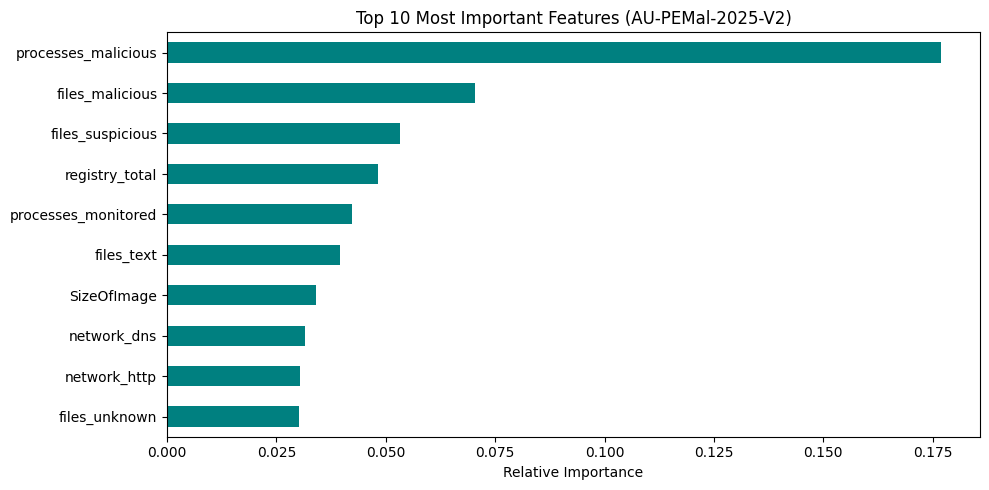

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load the cleaned dataset
df = pd.read_csv("AU-PEMal-2025-V2_Cleaned.csv")

# 2. Select Target (Family multi-class) and Features
target_col = "Family"  # Options: 'Class', 'Category', 'Family'

le = LabelEncoder()
y = le.fit_transform(df[target_col])

# Drop all 3 target columns from Feature matrix X
X = df.drop(columns=["Class", "Category", "Family"])

# 3. Stratified Train / Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Evaluate Performance
y_pred = model.predict(X_test)
class_names = le.classes_

print("================ CLASSIFICATION REPORT ================")
print(
    classification_report(y_test, y_pred, target_names=class_names, digits=4)
)

# 6. Plot & Download Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10)

plt.figure(figsize=(10, 5))
top_10.plot(kind="barh", color="teal")
plt.title("Top 10 Most Important Features (AU-PEMal-2025-V2)")
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("v2_feature_importance.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files

# Trigger direct browser download in Colab
files.download("AU-PEMal-2025-V2_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>